# Project: Imbalanced Classification

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

### 2. Load Dataset

In [2]:
url = "https://raw.githubusercontent.com/Saiful-2/datasets/main/telco-customer-churn.csv"
df = pd.read_csv(url)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### 3. Basic Info

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### 4. Data Cleaning

In [4]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Handle missing values
df.dropna(inplace=True)

# Drop customerID
df.drop('customerID', axis=1, inplace=True)

### 5. Target Variable Encoding

In [5]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

### 6. Check Class Imbalance

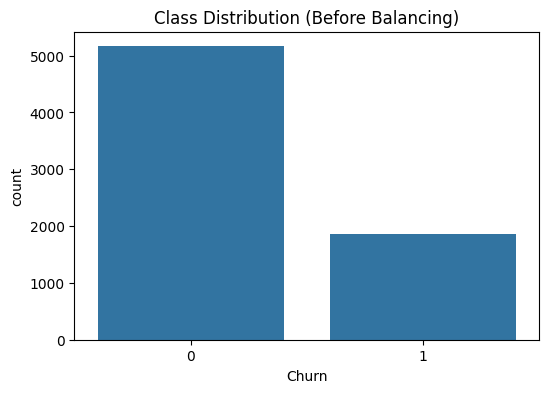

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Class Distribution (Before Balancing)")
plt.show()

print(df['Churn'].value_counts(normalize=True))

Majority: No churn

Minority: Churn
➡️ This is imbalanced dataset

### 7. Encode Categorical Features

In [7]:
categorical_cols = df.select_dtypes(include=['object']).columns

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

### 8. Train-Test Split

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### 9. Feature Scaling

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## PART 1: Model WITHOUT Handling Imbalance
### 10. Logistic Regression (Baseline)

In [10]:
lr = LogisticRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("=== WITHOUT BALANCING ===")
print(classification_report(y_test, y_pred))

=== WITHOUT BALANCING ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Confusion Matrix

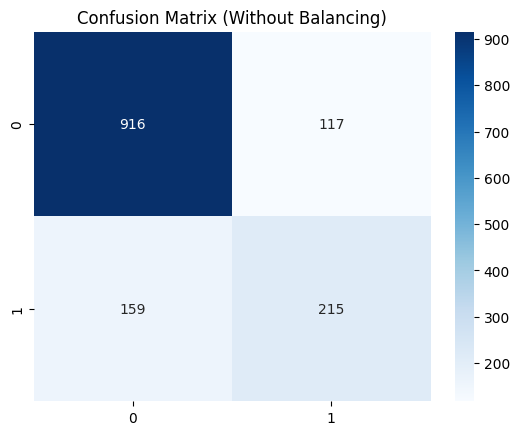

In [11]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Without Balancing)")
plt.show()

### ROC-AUC

ROC-AUC: 0.8356727976766699


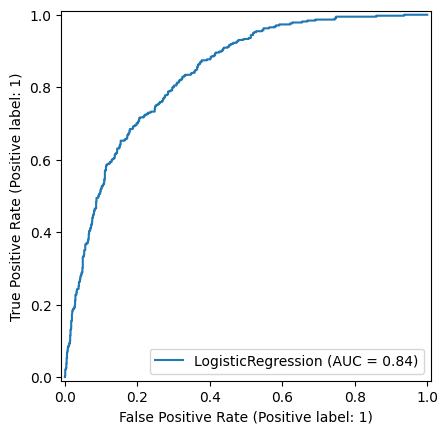

In [12]:
roc_auc = roc_auc_score(y_test, lr.predict_proba(X_test)[:,1])
print("ROC-AUC:", roc_auc)

RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.show()

## PART 2: Handle Imbalance using SMOTE
### 11. Apply SMOTE

In [13]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Before:", y_train.value_counts())
print("After:", pd.Series(y_train_smote).value_counts())

Before: Churn
0    4130
1    1495
Name: count, dtype: int64
After: Churn
0    4130
1    4130
Name: count, dtype: int64


### 12. Logistic Regression (After SMOTE)

In [14]:
lr_smote = LogisticRegression()
lr_smote.fit(X_train_smote, y_train_smote)

y_pred_smote = lr_smote.predict(X_test)

print("=== WITH SMOTE ===")
print(classification_report(y_test, y_pred_smote))

=== WITH SMOTE ===
              precision    recall  f1-score   support

           0       0.90      0.71      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407



### Confusion Matrix

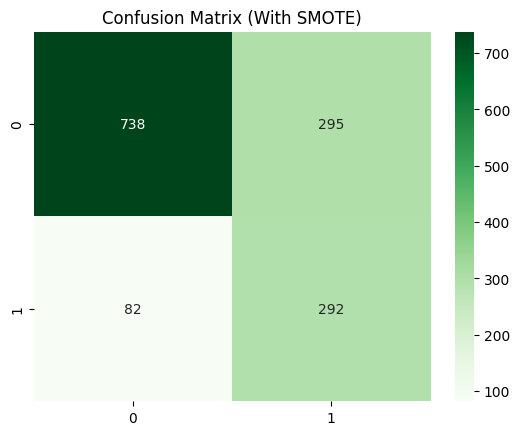

In [15]:
cm = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (With SMOTE)")
plt.show()

### ROC-AUC

ROC-AUC: 0.833891992069203


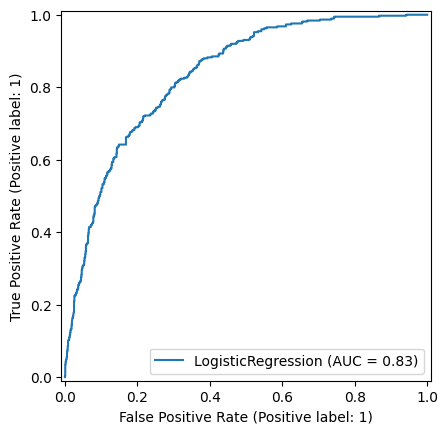

In [16]:
roc_auc = roc_auc_score(y_test, lr_smote.predict_proba(X_test)[:,1])
print("ROC-AUC:", roc_auc)

RocCurveDisplay.from_estimator(lr_smote, X_test, y_test)
plt.show()

## 13. Random Forest (After SMOTE)

In [17]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST WITH SMOTE ===")
print(classification_report(y_test, y_pred_rf))

=== RANDOM FOREST WITH SMOTE ===
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.58      0.61      0.60       374

    accuracy                           0.78      1407
   macro avg       0.72      0.73      0.72      1407
weighted avg       0.78      0.78      0.78      1407



### Confusion Matrix

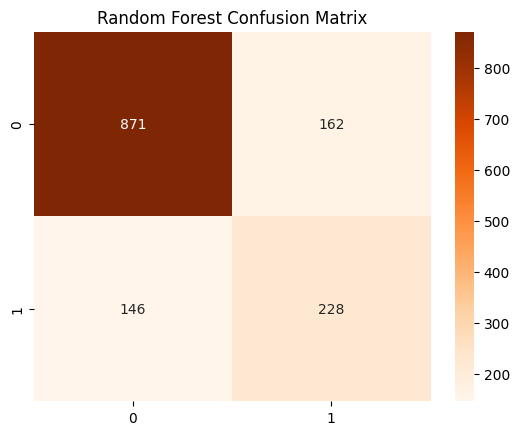

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Random Forest Confusion Matrix")
plt.show()

## 14. Model Comparison Summary

In [19]:
models = {
    "Logistic (No SMOTE)": lr,
    "Logistic (SMOTE)": lr_smote,
    "Random Forest (SMOTE)": rf
}

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:,1]
    score = roc_auc_score(y_test, y_prob)
    print(f"{name}: ROC-AUC = {score:.4f}")

Logistic (No SMOTE): ROC-AUC = 0.8357
Logistic (SMOTE): ROC-AUC = 0.8339
Random Forest (SMOTE): ROC-AUC = 0.8171


## 15. Key Insights

1. Dataset is highly imbalanced → affects model performance
2. Without SMOTE:
   - Model favors majority class
   - Poor recall for churn customers

3. With SMOTE:
   - Better detection of churn customers
   - Improved recall & F1-score

4. Random Forest performs better than Logistic Regression

BUSINESS IMPACT:
- Identifying churn customers early helps reduce revenue loss
- Balanced models improve decision-making